# 05 Result Analysis

Local notebook for post-training metrics/table/figure analysis.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve().parent
OUT = Path(r"C:\Users\votranhuonggiang\OneDrive\ドキュメント\Python\MiQuant\Training\MomentumTransformer\vn30f1m_momentum_transformer\outputs\vn30f1m_outputs_version1")
print('OUT:', OUT)

OUT: C:\Users\votranhuonggiang\OneDrive\ドキュメント\Python\MiQuant\Training\MomentumTransformer\vn30f1m_momentum_transformer\outputs\vn30f1m_outputs_version1


In [2]:
model_cmp = pd.read_csv(OUT / 'tables' / 'model_comparison_metrics.csv')
trade_stats = pd.read_csv(OUT / 'tables' / 'trade_statistics.csv')
wf = pd.read_csv(OUT / 'tables' / 'walk_forward_results.csv')

display(model_cmp.sort_values('sharpe_ratio', ascending=False))
display(trade_stats)
display(wf.head())

,model,total_return,sharpe_ratio,max_drawdown,profit_factor
0,lstm_dmn,0.029787,5.216325,-0.015529,1.133994
1,decoder_transformer,0.071485,4.163133,-0.046716,1.062325
2,decoder_tft,0.094313,3.976641,-0.051864,1.058606
3,ema_cross_8_24,0.066651,1.262071,-0.094335,0.263063
4,macd_8_24,0.066651,1.262071,-0.094335,0.263063
5,long_only,-0.020764,0.319477,-0.145374,0.829280
6,macd_32_96,0.038807,-0.769575,-0.101003,0.706670
7,ema_cross_32_96,0.038807,-0.769575,-0.101003,0.706670
8,ema_cross_16_48,-0.006518,-1.177772,-0.121093,0.410888
9,macd_16_48,-0.006518,-1.177772,-0.121093,0.410888


,model,number_of_trades,turnover,average_net_pnl_points,percentage_time_long,percentage_time_short,percentage_time_flat
0,decoder_tft,30323,6163.496487,0.020998,0.265691,0.572399,0.161910
1,decoder_transformer,28621,5809.499438,0.019239,0.366511,0.414228,0.219260
2,ema_cross_16_48,1947,2520.000000,0.001927,0.510890,0.443338,0.045773
3,ema_cross_32_96,1648,1926.000000,0.011273,0.540567,0.416771,0.042661
4,ema_cross_8_24,2581,3772.000000,0.020197,0.497158,0.454915,0.047927
5,long_only,1338,1338.000000,-0.002755,0.919943,0.000000,0.080057
6,lstm_dmn,18020,2422.095447,0.007676,0.211303,0.250165,0.538533
7,macd_16_48,1947,2520.000000,0.001927,0.510890,0.443338,0.045773
8,macd_32_96,1648,1926.000000,0.011273,0.540567,0.416771,0.042661
9,macd_8_24,2581,3772.000000,0.020197,0.497158,0.454915,0.047927


,total_return,annualized_return,annualized_volatility,sharpe_ratio,sortino_ratio,max_drawdown,calmar_ratio,hit_rate,profit_factor,average_trade_pnl,average_win,average_loss,win_loss_ratio,number_of_trades,turnover,window,model
0,-0.136023,-0.733322,0.365371,-3.617418,-4.125526,-0.171528,-4.275241,0.443703,0.848448,-0.096512,2.144615,-0.851295,2.519238,258,258.0,wf_1_2021-07-01_2021-12-31,long_only
1,0.069970,1.034632,0.369125,1.924333,2.759493,-0.080489,12.854249,0.432382,0.153511,-1.135072,1.370659,-1.577884,0.868669,1112,1846.0,wf_1_2021-07-01_2021-12-31,tsmom_12
2,0.028245,0.394203,0.368481,0.901874,1.280960,-0.133011,2.963683,0.435174,0.163444,-1.070957,1.211465,-1.547473,0.782866,909,1486.0,wf_1_2021-07-01_2021-12-31,tsmom_24
3,0.077842,1.180460,0.368061,2.117969,2.977359,-0.073166,16.134027,0.448046,0.269764,-0.937255,1.842609,-1.580483,1.165852,612,922.0,wf_1_2021-07-01_2021-12-31,tsmom_48
4,-0.024917,-0.157982,0.368119,-0.467116,-0.636304,-0.093161,-1.695799,0.458902,0.246410,-0.919646,1.618095,-1.498913,1.079512,565,840.0,wf_1_2021-07-01_2021-12-31,tsmom_78


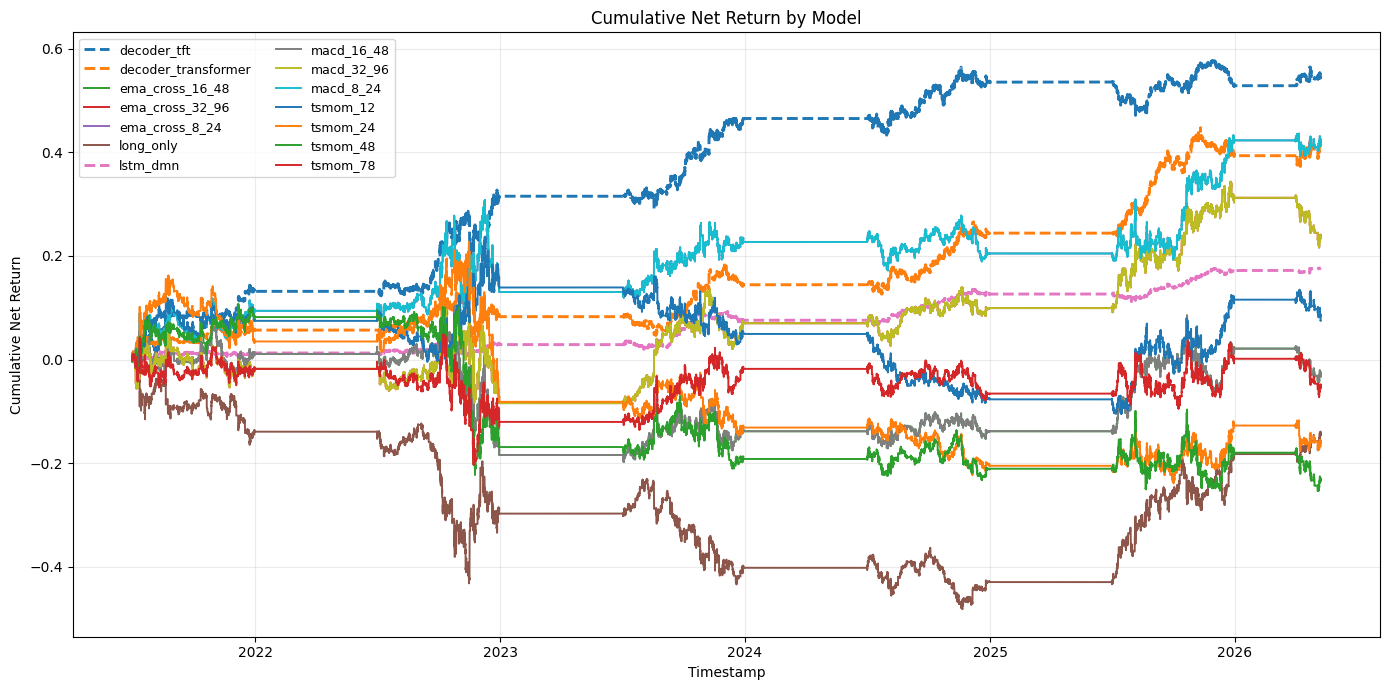

In [3]:
pred = pd.read_csv(OUT / 'predictions' / 'all_predictions.csv', parse_dates=['timestamp'])
pred = pred.sort_values(['model', 'timestamp'])
pred['cum_net_return'] = pred.groupby('model')['net_return'].cumsum()

focus_models = {'lstm_dmn', 'decoder_transformer', 'decoder_tft'}

plt.figure(figsize=(14, 7))
for model_name, g in pred.groupby('model'):
    ls = '--' if model_name in focus_models else '-'
    lw = 2.1 if model_name in focus_models else 1.4
    plt.plot(g['timestamp'], g['cum_net_return'], label=model_name, linewidth=lw, linestyle=ls)
plt.title('Cumulative Net Return by Model')
plt.xlabel('Timestamp')
plt.ylabel('Cumulative Net Return')
plt.grid(alpha=0.25)
plt.legend(loc='best', ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

In [4]:
fig_path = OUT / 'figures' / 'model_cumulative_returns.png'
print('Saved figure exists:', fig_path.exists(), fig_path)

Saved figure exists: True C:\Users\votranhuonggiang\OneDrive\ドキュメント\Python\MiQuant\Training\MomentumTransformer\vn30f1m_momentum_transformer\outputs\vn30f1m_outputs_version1\figures\model_cumulative_returns.png
